In [12]:
# Installing Libraries

!pip install transformers datasets -q

In [13]:
# Importing Functions

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import torch
import numpy as np
import pandas as pd
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

print("Torch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Torch version: 2.10.0+cu128
GPU available: True
Device: Tesla T4


In [14]:
# Loading Datasets

dataset = load_dataset("zeroshot/twitter-financial-news-sentiment")
print(dataset)
print("\nSample:")
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 9543
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2388
    })
})

Sample:
{'text': '$BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT', 'label': 0}


Label distribution: Counter({2: 6178, 1: 1923, 0: 1442})


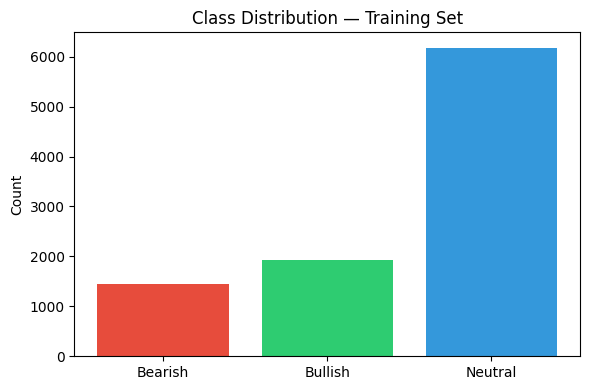


--- Bearish ---
  · $BYND - JPMorgan reels in expectations on Beyond Meat https://t.co/bd0xbFGjkT
  · $CCL $RCL - Nomura points to bookings weakness at Carnival and Royal Caribbean https://t.co/yGjpT2ReD3

--- Bullish ---
  · $ALTG: Dougherty & Company starts at Buy
  · $AMD - AMD's Navi shows strong adoption - BofA https://t.co/WnCksfl1gX

--- Neutral ---
  · $LB - MKM Partners puts a number on Victoria's Secret https://t.co/VSzHLqLBgE
  · $WING - Baird returns to Wingstop bull camp https://t.co/KfPaweOVgo


In [15]:
# Exploring Data

label_names = ["Bearish", "Bullish", "Neutral"]

# Class distribution
train_labels = dataset["train"]["label"]
label_counts = Counter(train_labels)
print("Label distribution:", label_counts)

# Plot
plt.figure(figsize=(6, 4))
plt.bar(
    [label_names[i] for i in sorted(label_counts.keys())],
    [label_counts[i] for i in sorted(label_counts.keys())],
    color=["#e74c3c", "#2ecc71", "#3498db"]
)
plt.title("Class Distribution — Training Set")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Sample tweets per class
for label_id, name in enumerate(label_names):
    print(f"\n--- {name} ---")
    samples = [x for x in dataset["train"] if x["label"] == label_id][:2]
    for s in samples:
        print(f"  · {s['text'][:120]}")

In [16]:
# Tokenizing

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized = dataset.map(tokenize, batched=True)
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

print("Done!")
print("Train size :", len(tokenized["train"]))
print("Val size   :", len(tokenized["validation"]))

Done!
Train size : 9543
Val size   : 2388


In [17]:
# Model Loading

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3
)

model.config.id2label = {0: "Bearish", 1: "Bullish", 2: "Neutral"}
model.config.label2id = {"Bearish": 0, "Bullish": 1, "Neutral": 2}

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded — {total_params:,} parameters")
print(f"Running on: {'GPU' if torch.cuda.is_available() else 'CPU'}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded — 66,955,779 parameters
Running on: GPU


In [18]:
# Computing Metrices
def compute_metrics(pred):
    labels = pred.label_ids
    preds  = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1"      : f1_score(labels, preds, average="weighted")
    }

In [19]:
#Training arguments

training_args = TrainingArguments(
    output_dir                  = "./results",
    num_train_epochs            = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    eval_strategy               = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1",
    warmup_steps                = 100,
    weight_decay                = 0.01,
    logging_steps               = 50,
    report_to                   = "none"
)

In [21]:
# Training 

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = tokenized["train"],
    eval_dataset    = tokenized["validation"],
    compute_metrics = compute_metrics
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.220878,0.874878,0.864322,0.866539
2,0.130550,1.015671,0.878978,0.879054
3,0.116099,1.135440,0.882747,0.883077


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=450, training_loss=0.15692088656955294, metrics={'train_runtime': 170.3225, 'train_samples_per_second': 168.087, 'train_steps_per_second': 2.642, 'total_flos': 948119197089024.0, 'train_loss': 0.15692088656955294, 'epoch': 3.0})

In [22]:
# Evaluate

results = trainer.evaluate()
print("\n=== Final Results ===")
for k, v in results.items():
    print(f"  {k}: {round(v, 4)}" if isinstance(v, float) else f"  {k}: {v}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



=== Final Results ===
  eval_loss: 1.1354
  eval_accuracy: 0.8827
  eval_f1: 0.8831
  eval_runtime: 4.0497
  eval_samples_per_second: 589.667
  eval_steps_per_second: 4.692
  epoch: 3.0


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


=== Classification Report ===
              precision    recall  f1-score   support

     Bearish       0.77      0.83      0.80       347
     Bullish       0.85      0.81      0.83       475
     Neutral       0.92      0.92      0.92      1566

    accuracy                           0.88      2388
   macro avg       0.85      0.85      0.85      2388
weighted avg       0.88      0.88      0.88      2388



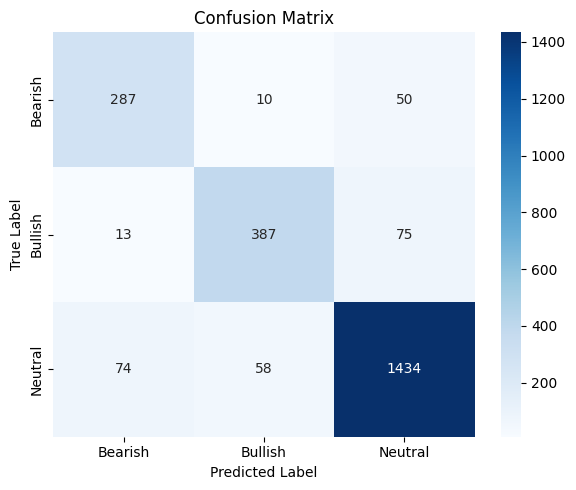

In [23]:
# Confusion Matrix

preds_output = trainer.predict(tokenized["validation"])
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

print("=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=label_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names
)
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [24]:
# Inference
def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to("cuda" if torch.cuda.is_available() else "cpu")

    model.to("cuda" if torch.cuda.is_available() else "cpu")

    with torch.no_grad():
        logits = model(**inputs).logits

    probs        = torch.softmax(logits, dim=1).squeeze().tolist()
    predicted_id = logits.argmax().item()

    print(f"Text       : {text}")
    print(f"Prediction : {label_names[predicted_id]}")
    for i, name in enumerate(label_names):
        bar = "█" * int(probs[i] * 20)
        print(f"  {name:<8} {bar:<20} {probs[i]*100:.1f}%")
    print()

# Test it
predict_sentiment("Apple stock hits all-time high as iPhone sales beat expectations")
predict_sentiment("Fed raises rates again, markets crash and investors panic")
predict_sentiment("Amazon reports quarterly earnings in line with forecasts")
predict_sentiment("Tesla shares drop 12% after missing delivery targets")
predict_sentiment("Goldman Sachs upgrades S&P 500 price target for 2024")

Text       : Apple stock hits all-time high as iPhone sales beat expectations
Prediction : Bullish
  Bearish                       0.0%
  Bullish  ███████████████████  99.9%
  Neutral                       0.0%

Text       : Fed raises rates again, markets crash and investors panic
Prediction : Neutral
  Bearish                       1.2%
  Bullish                       0.1%
  Neutral  ███████████████████  98.7%

Text       : Amazon reports quarterly earnings in line with forecasts
Prediction : Neutral
  Bearish                       0.1%
  Bullish                       0.8%
  Neutral  ███████████████████  99.2%

Text       : Tesla shares drop 12% after missing delivery targets
Prediction : Bearish
  Bearish  ███████████████████  99.8%
  Bullish                       0.1%
  Neutral                       0.1%

Text       : Goldman Sachs upgrades S&P 500 price target for 2024
Prediction : Bullish
  Bearish                       0.1%
  Bullish  ███████████████████  99.0%
  Neutral        

In [25]:
# Save Model

model.save_pretrained("./financial-sentiment-model")
tokenizer.save_pretrained("./financial-sentiment-model")
print("Model saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved!
